<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 13 <a name="PII513"></a>

Considere o campo de deslocamentos de um objeto dada por (unidades em mm):

\begin{equation*}
\vec{u} = k(x^2 + 2z) \vec\imath +
k(4x + 2y^2 + z) \vec\jmath + 4kz^2 \vec{k}
\end{equation*}

em que $k$ é uma constante pequena, na hipótese de estado de deformação infinitesimal.

[I](#I). Determine as deformações no ponto $(2,2,3)$ ao longo das direções:

a) $n_x = 0, n_y = 1/\sqrt{2}, n_z = 1/\sqrt{2}$

b) $n_x = 1, n_y =  n_z = 0$

c) $n_x = 0.6, n_y = 0, n_z = 0.8$

[II](#II).  Considere o valor $k=0,001$. Determine a variação do ângulo entre dois segmentos de reta $\overrightarrow{PQ}$ e $\overrightarrow{PR}$ no ponto $P(2,2,3)$ com os seguintes cossenos diretores:

a)

\begin{equation*}
\begin{aligned}[t]
\vec{n}_{PQ}~&:~n_{x_1} = 0, n_{y_1} = n_{z_1} = \frac{1}{\sqrt{2}}\\
\vec{n}_{PR}~&:~n_{x_2} = 1, n_{y_2} = n_{z_2} = 0
\end{aligned}
\end{equation*}

b)

\begin{equation*}
\begin{aligned}[t]
\vec{n}_{PQ}~&:~n_{x_1} = 0, n_{y_1} = n_{z_1} = \frac{1}{\sqrt{2}}\\
\vec{n}_{PR}~&:~n_{x_2} = 0.6, n_{y_2} = 0, n_{z_2} = 0.8
\end{aligned}
\end{equation*}

c)

\begin{equation*}
\begin{aligned}[t]
\vec{n}_{PQ}~&:~n_{x_1} = 1, n_{y_1} = n_{z_1} = 0\\
\vec{n}_{PR}~&:~n_{x_2} = 0.6, n_{y_2} = 0, n_{z_2} = 0.8
\end{aligned}
\end{equation*}

## Resolução

#### I) Determine as deformações no ponto $(2,2,3)$ ao longo das direções $n_1$, $n_2$  e $n_3$.<a name="I"></a>

([enunciatum](#PII513))

Versor n1:  [ 0.000  0.707  0.707]
Versor n2:  [1 0 0]
Versor n3:  [ 0.600  0.000  0.800]


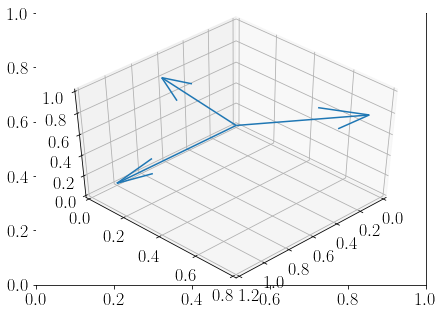

In [20]:
import numpy as np
import sympy as sy
from sympy import diff
from sympy import symbols
import matplotlib.pyplot as plt

def versor(l,m,n): return np.array([l,m,n])

# versor 1:
n1x = 0
n1y = 1/np.sqrt(2)
n1z = 1/np.sqrt(2)

np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
n1 = versor(n1x,n1y,n1z)
print('Versor n1: ',n1)

# versor 2:
n2x = 1; n2y = 0; n2z = 0
n2 = versor(n2x,n2y,n2z)
print('Versor n2: ',n2)

# versor 3:
n3x = 0.6; n3y = 0; n3z = 0.8
n3 = versor(n3x,n3y,n3z)
print('Versor n3: ',n3)

veta = np.array([[0, 0, 0, n1x, n1y, n1z]])
Xa, Ya, Za, Ua, Va, Wa = zip(*veta)
vetb = np.array([[0, 0, 0, n2x, n2y, n2z]])
Xb, Yb, Zb, Ub, Vb, Wb = zip(*vetb)
vetc = np.array([[0, 0, 0, n3x, n3y, n3z]])
Xc, Yc, Zc, Uc, Vc, Wc = zip(*vetc)

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=18)
fig, ax = plt.subplots(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(Xa, Ya, Za, Ua, Va, Wa)
ax.quiver(Xb, Yb, Zb, Ub, Vb, Wb)
ax.quiver(Xc, Yc, Zc, Uc, Vc, Wc)
ax.set_xlim([0, 1.2])
ax.set_ylim([0, .8])
ax.set_zlim([0, 1.])
ax.view_init(45, 45)
plt.show()

In [21]:
u, v, w, x, y, z, k = symbols('u v w x y z k')

def ux(x,z,k): return k*(x**2 + 2*z)
def uy(x,y,z,k): return k*(4*x + 2*y**2 + z)
def uz(z,k): return 4*k*z**2

u1 = ux(x,z,k)
v1 = uy(x,y,z,k)
w1 = uz(z,k)

print('matriz das deformações [D]:\n')

exx = diff(u1, x)
print('exx = du/dx :',exx)
eyy = diff(v1, y)
print('eyy = dv/dy :',eyy)
ezz = diff(w1, z)
print('ezz = dw/dz :',ezz)
exy  = 0.5*(diff(u1, y) + diff(v1, x) )
print('exy = 1/2 gxy = 1/2 (du/dy + dv/dx )  :',exy)
exz  = 0.5*(diff(u1, z) + diff(w1, x) )
print('exz = 1/2 gxz = 1/2 (du/dz + dw/dx )  :',exz)
eyz  = 0.5*(diff(v1, z) + diff(w1, y) )
print('eyz = 1/2 gxy = 1/2 (dv/dz + dw/dy )  :',eyz)

def mD(exx,exy,exz,eyy,eyz,ezz):
    return np.array([[exx,exy,exz],[exy,eyy,eyz],[exz,eyz,ezz]])

np.set_printoptions(formatter={'float': '{: 0.3f}'.format})
mD0 = mD(exx,exy,exz,eyy,eyz,ezz)
print('\n[mD0] = \n',mD0)

matriz das deformações [D]:

exx = du/dx : 2*k*x
eyy = dv/dy : 4*k*y
ezz = dw/dz : 8*k*z
exy = 1/2 gxy = 1/2 (du/dy + dv/dx )  : 2.0*k
exz = 1/2 gxz = 1/2 (du/dz + dw/dx )  : 1.0*k
eyz = 1/2 gxy = 1/2 (dv/dz + dw/dy )  : 0.5*k

[mD0] = 
 [[2*k*x 2.0*k 1.0*k]
 [2.0*k 4*k*y 0.5*k]
 [1.0*k 0.5*k 8*k*z]]


Matriz das deformações:

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}} \equiv [\varepsilon] \equiv \varepsilon_{ij}
&=
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz}\\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{yz}/2 & \varepsilon_{zz} \\
\end{bmatrix} \\
&=
\begin{bmatrix}
\displaystyle\frac{\partial u}{\partial x}
& \displaystyle\frac{1}{2}\left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
& \displaystyle\frac{1}{2}\left(\frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) \\
\displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right)
& \displaystyle\frac{\partial v}{\partial y}
& \displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right) \\
\displaystyle\frac{1}{2}\left(\frac{\partial w}{\partial x} + \frac{\partial u}{\partial z} \right)
& \displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)
& \displaystyle\frac{\partial w}{\partial z} \\
\end{bmatrix} \\
&=k
\begin{bmatrix}
2x & 2 & 1 \\
2 & 4y & 0.5\\
1 & 0.5 & 8z
\end{bmatrix}
\end{aligned}
\end{equation*}

In [22]:
Px0 = 2
Py0 = 2
Pz0 = 3

print('\nPonto =',Px0,Py0,Pz0)

exx = exx.subs({x:Px0,y:Py0,z:Pz0,k:k})
eyy = eyy.subs({x:Px0,y:Py0,z:Pz0,k:k})
ezz = ezz.subs({x:Px0,y:Py0,z:Pz0,k:k})
exy = exy.subs({x:Px0,y:Py0,z:Pz0,k:k})
exz = exz.subs({x:Px0,y:Py0,z:Pz0,k:k})
eyz = eyz.subs({x:Px0,y:Py0,z:Pz0,k:k})

mDP = mD(exx,exy,exz,eyy,eyz,ezz)
print('\n[D(P)] = \n',mDP)


Ponto = 2 2 3

[D(P)] = 
 [[4*k 2.0*k 1.0*k]
 [2.0*k 8*k 0.5*k]
 [1.0*k 0.5*k 24*k]]


A deformação linear infinitesimal numa determinada direção definida pelo versor $\vec{n}$ é dada por:

\begin{equation*}
\begin{aligned}
\varepsilon(\vec{n}) &=
{n}^T[D]\{n\} = k
\begin{bmatrix}
l & m & n
\end{bmatrix}
\begin{bmatrix}
2x & 2 & 1 \\
2 & 4y & 0.5\\
1 & 0.5 & 8z
\end{bmatrix}
\begin{bmatrix}
l \\ m \\ n
\end{bmatrix}
\end{aligned}
\end{equation*}

Pelo que, para o ponto $P(2,2,3)$ vem:

\begin{equation*}
\begin{aligned}
\varepsilon(P,\vec{n}) &=
{n}^T[D]\{n\} = k
\begin{bmatrix}
l & m & n
\end{bmatrix}
\begin{bmatrix}
4 & 2 & 1 \\
2 & 8 & 0.5 \\
1 & 0.5 & 24
\end{bmatrix}
\begin{bmatrix}
l \\ m \\ n
\end{bmatrix}
\end{aligned}
\end{equation*}

In [23]:
print('-----------------------')
print('Versor 1:')
print('-----------------------')
epsN1 = np.dot(np.transpose(n1),np.dot(mD0,n1))
print('eps( n1 ) = ',sy.simplify(sy.expand(epsN1)))
epsPN1 = epsN1.subs({x:Px0,y:Py0,z:Pz0,k:k})
print('eps( P,n1 ) =',epsPN1)

print('-----------------------')
print('Versor 2:')
print('-----------------------')
epsN2 = np.dot(np.transpose(n2),np.dot(mD0,n2))
print('eps( n2 ) = ',sy.simplify(sy.expand(epsN2)))
epsPN2 = epsN2.subs({x:Px0,y:Py0,z:Pz0,k:k})
print('eps( P,n2 ) =',epsPN2)

print('-----------------------')
print('Versor 3:')
print('-----------------------')
epsN3 = np.dot(np.transpose(n3),np.dot(mD0,n3))
print('eps( n2 ) = ',sy.simplify(sy.expand(epsN3)))
epsPN3 = epsN3.subs({x:Px0,y:Py0,z:Pz0,k:k})
print('eps( P,n2 ) =',epsPN3)

-----------------------
Versor 1:
-----------------------
eps( n1 ) =  k*(2.0*y + 4.0*z + 0.5)
eps( P,n1 ) = 16.5*k
-----------------------
Versor 2:
-----------------------
eps( n2 ) =  2*k*x
eps( P,n2 ) = 4*k
-----------------------
Versor 3:
-----------------------
eps( n2 ) =  k*(0.72*x + 5.12*z + 0.96)
eps( P,n2 ) = 17.76*k


#### II) Determine a variação do ângulo entre segmentos.<a name="II"></a>

([enunciatum](#PII513))

Esta expressão para o cálculo da deformação linear na direção $\vec{n}=l\vec{\imath}+m\vec{\jmath}+n\vec{k}$ pode ainda ser obtida diretamente pela seguinte expressão analítica:

\begin{equation*}
\varepsilon(P,\vec{n}) = \varepsilon_{xx}l^2 + \varepsilon_{yy}m^2 + \varepsilon_{zz}n^2 +
\gamma_{xy}lm + \gamma_{xz}ln + \gamma_{yz}mn
\end{equation*}

A dirtorção angular em função das deformações infinitesimais (condições: (i) $(1+\varepsilon_1)(1+\varepsilon_2) \approx 1 $, (ii) $\sin\gamma_{12} \approx \gamma_{12}$.

\begin{equation*}
\begin{aligned}
\cos\theta' & \approx
\cos\theta +
2\{n\}_1^{T}[D]\{n\}_2  = \cos\theta + \gamma_{12}
\end{aligned}
\end{equation*}

com,

\begin{equation*}
\cos\theta  = \frac{\vec{V}_1 \cdot \vec{V}_2}{V_1V_2}
= l_{1}l_{2} + m_{1}m_{2} + n_{1}n_{2}
\end{equation*}

e,

\begin{equation*}
\begin{aligned}
\gamma_{12} &= 2 \{n\}_1^T [D]\{n\}_2 \\
&= 2\varepsilon_{xx}l_1l_2 + 2\varepsilon_{yy}m_1m_2 + 2\varepsilon_{zz}n_1n_2 + \gamma_{xy}(l_1m_2 + l_2m_1)
+ \gamma_{xz}(l_1n_2 + l_2n_1) + \gamma_{yz}(m_1n_2 + m_2n_1)
\end{aligned}
\end{equation*}

In [24]:
k1 = 0.001 # assumindo um valor pequeno para k
exx = exx.subs({x:Px0,y:Py0,z:Pz0,k:k1})
eyy = eyy.subs({x:Px0,y:Py0,z:Pz0,k:k1})
ezz = ezz.subs({x:Px0,y:Py0,z:Pz0,k:k1})
exy = exy.subs({x:Px0,y:Py0,z:Pz0,k:k1})
exz = exz.subs({x:Px0,y:Py0,z:Pz0,k:k1})
eyz = eyz.subs({x:Px0,y:Py0,z:Pz0,k:k1})

mDPk = mD(exx,exy,exz,eyy,eyz,ezz)
print('\n[D(P)] = \n',mDPk)

def deflinear(exx,eyy,ezz,gxy,gxz,gyz,l,m,n):
    return exx*l**2 + eyy*m**2 + ezz*n**2 + gxy*l*m + gxz*l*n + gyz*m*n

def defangular(exx,eyy,ezz,gxy,gxz,gyz,l1,m1,n1,l2,m2,n2):
    return 2*exx*l1*l2 + 2*eyy*m1*m2 + 2*ezz*n1*n2 + gxy*(l1*m2 + l2*m1) + gxz*(l1*n2 + l2*n1) + gyz*(m1*n2 + m2*n1)

print('\nDeformação linear no ponto P e na direção n1 :..............:')
epsPN1v2 = deflinear(exx,eyy,ezz,2*exy,2*exz,2*eyz,n1x,n1y,n1z)
print('eps( P,n1 ) (eq. analítica) =','{:.5f}'.format(epsPN1v2))
epsPN2v2 = deflinear(exx,eyy,ezz,2*exy,2*exz,2*eyz,n2x,n2y,n2z)
print('eps( P,n1 ) (eq. analítica) =','{:.5f}'.format(epsPN2v2))
epsPN3v2 = deflinear(exx,eyy,ezz,2*exy,2*exz,2*eyz,n3x,n3y,n3z)
print('eps( P,n1 ) (eq. analítica) =','{:.5f}'.format(epsPN3v2))

print('-----------------------')
print('Segmentos n1 & n2 :')
print('-----------------------')
costhetaIn1n2 = np.dot(n1,n2)
thetaIn1n2 = np.arccos(costhetaIn1n2)
thetaIn1n2Deg = np.rad2deg(thetaIn1n2)
print('inicial cos (theta) = ','{:.3f}'.format(costhetaIn1n2))
print('              theta = ','{:.3f}'.format(thetaIn1n2Deg),' deg')

costhetaFn1n2 = float(costhetaIn1n2 + 2*np.dot(np.transpose(n1),np.dot(mDPk,n2)))
thetaFn1n2 = np.arccos(costhetaFn1n2)
thetaFn1n2Deg = np.rad2deg(thetaFn1n2)
print('final:  cos (theta) = ','{:.3f}'.format(costhetaFn1n2))
print('              theta = ','{:.3f}'.format(thetaFn1n2Deg),' deg')
print('  D theta ini - fin = ','{:.3f}'.format(thetaIn1n2Deg - thetaFn1n2Deg),' deg')

print('versão 2 :............................')
gn1n2 = float(defangular(exx,eyy,ezz,2*exy,2*exz,2*eyz,n1x,n1y,n1z,n2x,n2y,n2z))
tFn1n2Deg = np.rad2deg(np.arccos(gn1n2))
print('final:  cos (theta) = ','{:.3f}'.format(costhetaIn1n2 + gn1n2),' | theta =','{:.3f}'.format(tFn1n2Deg),'deg')

print('\n-----------------------')
print('Segmentos n1 & n3 :')
print('-----------------------')
costhetaIn1n3 = np.dot(n1,n3)
thetaIn1n3 = np.arccos(costhetaIn1n3)
thetaIn1n3Deg = np.rad2deg(thetaIn1n3)
print('inicial cos (theta) = ','{:.3f}'.format(costhetaIn1n3))
print('              theta = ','{:.3f}'.format(thetaIn1n3Deg),' deg')

costhetaFn1n3 = float(costhetaIn1n3 + 2*np.dot(np.transpose(n1),np.dot(mDPk,n3)))
thetaFn1n3 = np.arccos(costhetaFn1n3)
thetaFn1n3Deg = np.rad2deg(thetaFn1n3)
print('final:  cos (theta) = ','{:.3f}'.format(costhetaFn1n3))
print('              theta = ','{:.3f}'.format(thetaFn1n3Deg),' deg')
print('  D theta ini - fin = ','{:.3f}'.format(thetaIn1n3Deg - thetaFn1n3Deg),' deg')

print('versão 2 :............................')
gn1n3 = float(defangular(exx,eyy,ezz,2*exy,2*exz,2*eyz,n1x,n1y,n1z,n3x,n3y,n3z))
costhetaFn1n3v2 = float(costhetaIn1n3 + gn1n3)
thetaFn1n3v2 = np.arccos(costhetaFn1n3v2)
thetaFn1n3v2Deg = np.rad2deg(thetaFn1n3v2)
print('final:  cos (theta) = ','{:.3f}'.format(costhetaFn1n3v2),' | theta =','{:.3f}'.format(thetaFn1n3v2Deg),'deg')

print('\n-----------------------')
print('Segmentos n2 & n3 :')
print('-----------------------')
costhetaIn2n3 = np.dot(n2,n3)
thetaIn2n3 = np.arccos(costhetaIn2n3)
thetaIn2n3Deg = np.rad2deg(thetaIn2n3)
print('inicial cos (theta) = ','{:.3f}'.format(costhetaIn2n3))
print('              theta = ','{:.3f}'.format(thetaIn2n3Deg),' deg')

costhetaFn2n3 = float(costhetaIn2n3 + 2*np.dot(np.transpose(n2),np.dot(mDPk,n3)))
thetaFn2n3 = np.arccos(costhetaFn2n3)
thetaFn2n3Deg = np.rad2deg(thetaFn2n3)
print('final:  cos (theta) = ','{:.3f}'.format(costhetaFn2n3))
print('              theta = ','{:.3f}'.format(thetaFn2n3Deg),' deg')
print('  D theta ini - fin = ','{:.3f}'.format(thetaIn2n3Deg - thetaFn2n3Deg),' deg')

print('versão 2 :............................')
gn2n3 = float(defangular(exx,eyy,ezz,2*exy,2*exz,2*eyz,n2x,n2y,n2z,n3x,n3y,n3z))
costhetaFn2n3v2 = float(costhetaIn2n3 + gn2n3)
thetaFn2n3v2 = np.arccos(costhetaFn2n3v2)
thetaFn2n3v2Deg = np.rad2deg(thetaFn2n3v2)
print('final:  cos (theta) = ','{:.3f}'.format(costhetaFn2n3v2),' | theta =','{:.3f}'.format(thetaFn2n3v2Deg),'deg')


[D(P)] = 
 [[0.00400000000000000 0.00200000000000000 0.00100000000000000]
 [0.00200000000000000 0.00800000000000000 0.000500000000000000]
 [0.00100000000000000 0.000500000000000000 0.0240000000000000]]

Deformação linear no ponto P e na direção n1 :..............:
eps( P,n1 ) (eq. analítica) = 0.01650
eps( P,n1 ) (eq. analítica) = 0.00400
eps( P,n1 ) (eq. analítica) = 0.01776
-----------------------
Segmentos n1 & n2 :
-----------------------
inicial cos (theta) =  0.000
              theta =  90.000  deg
final:  cos (theta) =  0.004
              theta =  89.757  deg
  D theta ini - fin =  0.243  deg
versão 2 :............................
final:  cos (theta) =  0.004  | theta = 89.757 deg

-----------------------
Segmentos n1 & n3 :
-----------------------
inicial cos (theta) =  0.566
              theta =  55.550  deg
final:  cos (theta) =  0.596
              theta =  53.420  deg
  D theta ini - fin =  2.130  deg
versão 2 :............................
final:  cos (theta) =  0.596  

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>